<a href="https://colab.research.google.com/github/jade653/Algorithms-Analysis/blob/main/1_Calculation_of_Fibonacci_Numbers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Calculation of Fibonacci Numbers

## Basic
F0 =0; F1 =1, <br>
Fn =Fn-1 +Fn-2, n >= 2 <br>
just translate the recurrence in code

In [ ]:
def fib(n):
  if n==0:
    return 0
  if n==1:
    return 1
  else:
    return fib(n-1)+fib(n-2)

In [ ]:
fib(40)

102334155

It took 26s to caculate fib(40).

### Q1. Why this takes too long?<br>
It is because the function fib() is a recursive function. It should caculate fib(n-1) and fib(n-2) and then calculate the sum. Let's caculate the running time.<br>
#### **T(n) : the number of calls**
Let T(n) be the number of calls to fib() when fib(n) runs.
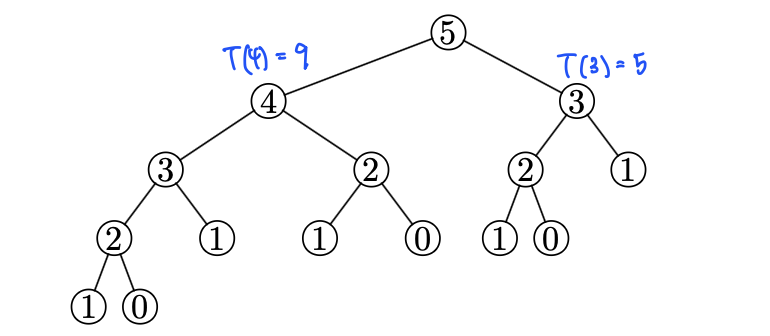
We can see T(n) = T(n-1) + T (n-2) + 1. As its initial conditions, we have T(0)=1; T(1)=1.<br>
T(n) is closely related to the recursive function for Fibonacci numbers. It is easy to see that T(n) ≥F (n) : same order as Fibonacci.
<br>You should know that fibonacci is linear recurrence which means it has an exponential form. So we can describe it like: <br>
F_n ≈ (1/√5) * φ^n, where φ = (1+√5)/2 ≈ 1.618
<br>F_n is an exponentially growing function, and therefore, T(n) also grows quickly. So as n grows, the running time of fib(n) grows exponentially large.

### Q2. How to make a computer efficent as people do? Or better?<br>
-> using **dynamic programming**<br>

## Dynamic programming
Simplifying a complicated problem by breaking it down into simpler sub-problem in a recursive manner.

### the way humans caculate

In [ ]:
def fib2(n):
  if n==0:
    return 0
  if n==1:
    return 1
  else:
    a, b = 0, 1
    for _ in range(2, n+1):
      a, b = b, a+b
    return b

In [ ]:
fib2(40)

102334155

### use memoization

In [ ]:
def fib3(n, memo={}):
  if n in memo:
    return memo[n]
  if n == 0:
    return 0
  if n == 1:
    return 1
  else:
    memo[n]=fib3(n-1, memo) + fib3(n-2, memo)
    return memo[n]


In [ ]:
fib3(40)

102334155

Both caculation fib2(40), fib3(40) took about 0s.
<br>
Solutions of many problems are described by **recursions**, as with Fibonacci numbers.<br>
Dynamic programming provides a way to compute the solutions efficiently.

## C version of fib2()

With C code, we can see F(100)is incorrect and even F(200) becomes a negative number. It is because normal fixed-size integer in C is 32-bit or 64-bit. But python supports multiple precision so integer in python can grow as large as needed.<br>This is my Week1 homework. <br>Complete a C program to calculate a table of F_n for n=0~1000. Make it able to add 209 decimal digits without using multiple precism library.

In [3]:
#include <stdio.h>
#define N 209  // The 1000th Fibonacci number has 209 decimal digits.

void print_digits(char d[N])
{
    int i = 0;

    while (d[i] == 0)
        i++;

    while (i < N)
        printf("%d", d[i++]);  // "%d" instead of "%c"
}

// Add aa and bb and store the result in bb.
// aa is assumed to be always larger.
void add_digits(char aa[N], char bb[N])
{
    int i = 0;
    int carry = 0;
    int j, s;

    while (aa[i] == 0)  // after loop, i is the first "non-zero" place
        i++;

    for (j = N - 1; j >= i - 1; j--) {  // the sum can have non-zero at (i-1)th place
        if ((s = carry + aa[j] + bb[j]) > 9) {
            bb[j] = s - 10;
            carry = 1;
        } else {
            bb[j] = s;
            carry = 0;
        }
    }
}

int main() {
    char aa[N], bb[N], temp[N];
    int i, j;

    for (j = 0; j < N; j++) {
        aa[j] = 0;
        bb[j] = 0;
    }

    aa[N - 1] = 0;
    bb[N - 1] = 1;

    for (i = 0; i <= 1000; i++) {

        if (i == 0) {
            print_digits(aa);
            printf("\n");
        }
        else if (i == 1) {
            print_digits(bb);
            printf("\n");
        }
        else {
            for (j = 0; j < N; j++)
                temp[j] = bb[j];

            add_digits(aa, bb);
            print_digits(bb);
            printf("\n");

            for (j = 0; j < N; j++)
                aa[j] = temp[j];
        }
    }

    return 0;
}


SyntaxError: invalid syntax (2065494327.py, line 1)